In [4]:
# need these to build the model and check how well it does
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

print("all good!")

all good!


In [5]:
# loading the iris dataset - classic flower dataset
# 150 flowers, 4 measurements each, 3 possible species
df = pd.read_csv('1) iris.csv')

# X is the flower measurements, y is the species we want to predict
X = df.drop('species', axis=1)
y = df['species']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("dataset loaded!")
print("training size:", X_train.shape)
print("testing size:", X_test.shape)
print()
print(df.head())

dataset loaded!
training size: (120, 4)
testing size: (30, 4)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
# splitting into features and target
# X is the 4 measurements of each flower
# y is the species we want to predict

X = df.drop('species', axis=1)
y = df['species']

# split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("training size:", X_train.shape)
print("testing size:", X_test.shape)

training size: (120, 4)
testing size: (30, 4)


In [7]:
# random forest = 100 trees all voting on the answer
# majority vote wins - way more reliable than just one tree
# max_depth stops trees from overfit ting by memorising the data

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# train it
model.fit(X_train, y_train)

# make predictions on data it hasnt seen
y_pred = model.predict(X_test)

print("model trained!")
print()
print("first 10 predictions vs actual:")
for pred, actual in zip(y_pred[:10], y_test[:10]):
    result = "YES" if pred == actual else "NO"
    print(f"predicted: {pred} | actual: {actual} {result}")

model trained!

first 10 predictions vs actual:
predicted: versicolor | actual: versicolor YES
predicted: setosa | actual: setosa YES
predicted: virginica | actual: virginica YES
predicted: versicolor | actual: versicolor YES
predicted: versicolor | actual: versicolor YES
predicted: setosa | actual: setosa YES
predicted: versicolor | actual: versicolor YES
predicted: virginica | actual: virginica YES
predicted: versicolor | actual: versicolor YES
predicted: versicolor | actual: versicolor YES


In [8]:
# checking how well the model actually did overall
# precision, recall and f1 score give a fuller picture than just accuracy

print("full model evaluation:")
print()
print(classification_report(y_test, y_pred))

# cross validation tests the model on different splits of the data
# gives a more honest picture of how it performs
scores = cross_val_score(model, X, y, cv=5)
print("cross validation scores:", scores.round(3))
print("average score:", round(scores.mean(), 3))

full model evaluation:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

cross validation scores: [0.967 0.967 0.933 0.967 1.   ]
average score: 0.967


feature importance:
petal_length    0.445
petal_width     0.421
sepal_length    0.106
sepal_width     0.028
dtype: float64



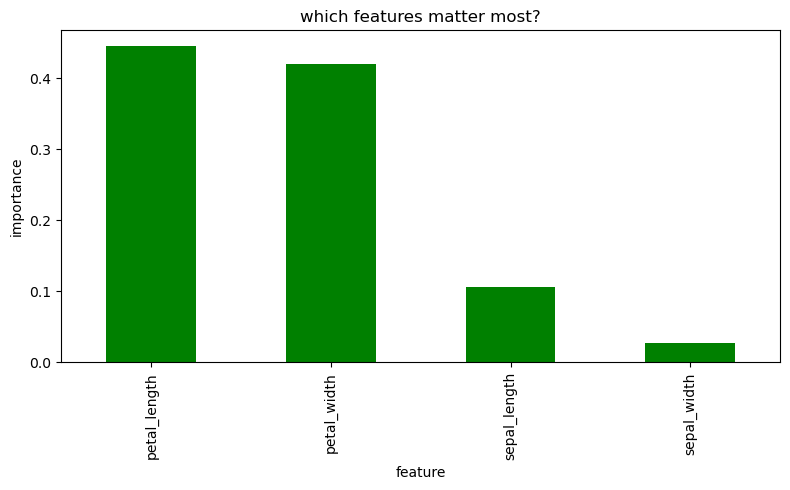

In [9]:
# which features did the model find most useful?
# higher value = more important for making the right prediction

feature_importance = pd.Series(model.feature_importances_, 
                               index=X.columns).sort_values(ascending=False)

print("feature importance:")
print(feature_importance.round(3))
print()

# plot it so its easier to see
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='green')
plt.title('which features matter most?')
plt.xlabel('feature')
plt.ylabel('importance')
plt.tight_layout()
plt.show()